# 第 4 节课 · 训练技巧消融实验

## 本 Notebook 目标

完成本 Notebook 后，你将能够：
1. 理解并对比 SGD、SGD+Momentum、Adam 三种优化器
2. 理解 BatchNorm 的作用和原理
3. 理解 Dropout 如何防止过拟合
4. 理解学习率调度（Step Decay、Cosine Annealing）的作用
5. 通过 4 组消融实验，直观感受每个训练技巧的效果

## 为什么要做消融实验？

深度学习中有很多训练技巧：
- 不同的优化器
- Batch Normalization
- Dropout
- 数据增强
- 学习率调度
- 权重衰减

这些技巧到底有多大用？不能只看论文里说的，要亲手实验才能理解。

**消融实验（Ablation Study）**就是：保持其他条件不变，只改变一个因素，看这个因素对结果的影响。

这节课我们用同一个网络结构，只改训练配置，看准确率怎么变。


## 0. 环境准备


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else
                     'mps' if torch.backends.mps.is_available() else
                     'cpu')
print(f"使用设备: {device}")


使用设备: cuda


## 1. 加载 CIFAR-10


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)
print("CIFAR-10 加载完成")


c:\Users\nan\miniconda3\envs\pytorch\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR-10 加载完成


## 2. 统一实验网络

为了公平对比所有训练技巧，我们固定网络结构，只通过参数控制是否使用 BatchNorm 和 Dropout。

网络结构：3 层 Conv + 2 层 FC


In [5]:
class SimpleNet(nn.Module):
    """
    统一的实验网络。
    通过 use_bn 和 use_dropout 控制是否使用 BatchNorm 和 Dropout。
    """
    def __init__(self, use_bn=True, use_dropout=True, dropout_p=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128) if use_bn else nn.Identity()
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(256) if use_bn else nn.Identity()
        self.use_dropout = use_dropout
        self.dropout = nn.Dropout(dropout_p)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        if self.use_dropout:
            x = self.dropout(x)
        x = self.fc2(x)
        return x


def train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion, scheduler=None):
    """统一的训练函数，用于所有消融实验。"""
    history = {'train_loss': [], 'test_acc': []}
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        test_acc = 100. * correct / total
        history['train_loss'].append(train_loss)
        history['test_acc'].append(test_acc)

        if scheduler is not None:
            scheduler.step()

        print(f"  Epoch {epoch}/{epochs}: Loss={train_loss:.4f}, Test Acc={test_acc:.2f}%")
    return history


## 3. 实验一：优化器对比

### 3.1 三种优化器简介

**SGD（随机梯度下降）**
$$\theta_{t+1} = \theta_t - \eta \nabla_\theta L$$

优点：简单，泛化性能通常较好
缺点：容易卡在平缓区域，收敛慢

**SGD + Momentum**
$$v_t = \beta v_{t-1} + \nabla_\theta L$$
$$\theta_{t+1} = \theta_t - \eta v_t$$

优点：有惯性，能加速收敛，减少震荡
缺点：需要调两个超参数

**Adam**
$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

优点：自适应学习率，收敛快，对超参数不敏感
缺点：有时候泛化不如 SGD+Momentum


In [6]:
epochs = 5
criterion = nn.CrossEntropyLoss()
experiments = []

print("\n【实验 A】SGD (lr=0.01, 无 Momentum)")
model = SimpleNet(use_bn=True, use_dropout=False).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion)
experiments.append(('SGD', '#c25e00', hist))

print("\n【实验 B】SGD + Momentum (lr=0.01, momentum=0.9)")
model = SimpleNet(use_bn=True, use_dropout=False).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion)
experiments.append(('SGD+Momentum', '#0d9f8f', hist))

print("\n【实验 C】Adam (lr=0.001)")
model = SimpleNet(use_bn=True, use_dropout=False).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion)
experiments.append(('Adam', '#d4a55f', hist))



【实验 A】SGD (lr=0.01, 无 Momentum)
  Epoch 1/5: Loss=1.4539, Test Acc=57.49%
  Epoch 2/5: Loss=1.0652, Test Acc=62.66%
  Epoch 3/5: Loss=0.9161, Test Acc=64.73%
  Epoch 4/5: Loss=0.8207, Test Acc=67.35%
  Epoch 5/5: Loss=0.7440, Test Acc=67.42%

【实验 B】SGD + Momentum (lr=0.01, momentum=0.9)
  Epoch 1/5: Loss=1.2010, Test Acc=67.03%
  Epoch 2/5: Loss=0.8305, Test Acc=70.72%
  Epoch 3/5: Loss=0.6750, Test Acc=76.06%
  Epoch 4/5: Loss=0.5593, Test Acc=77.07%
  Epoch 5/5: Loss=0.4680, Test Acc=77.36%

【实验 C】Adam (lr=0.001)
  Epoch 1/5: Loss=1.3583, Test Acc=65.73%
  Epoch 2/5: Loss=0.8470, Test Acc=72.76%
  Epoch 3/5: Loss=0.6847, Test Acc=72.23%
  Epoch 4/5: Loss=0.5810, Test Acc=72.58%
  Epoch 5/5: Loss=0.4843, Test Acc=76.62%


findfont: Failed to find font weight bold, now using 400.


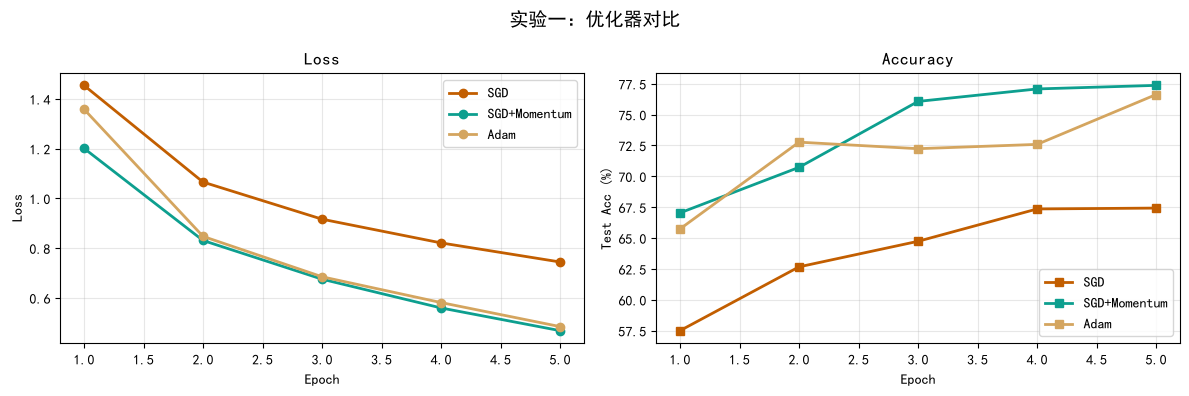

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, color, hist in experiments:
    e = list(range(1, len(hist['train_loss']) + 1))
    axes[0].plot(e, hist['train_loss'], 'o-', color=color, linewidth=2, label=name)
    axes[1].plot(e, hist['test_acc'], 's-', color=color, linewidth=2, label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Acc (%)'); axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('实验一：优化器对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 实验一分析

通常会看到：
- **SGD**：收敛最慢，但最终效果不一定差
- **SGD+Momentum**：收敛明显加快，震荡减少
- **Adam**：收敛最快，前几轮优势明显

实际经验：
- 快速验证想法：用 Adam
- 追求最终效果：用 SGD+Momentum，配合好的学习率调度


## 4. 实验二：BatchNorm 对比

### 4.1 什么是 BatchNorm？

Batch Normalization（批归一化）的核心思想：
> 对每一层的输出做标准化，使其均值为 0，方差为 1。

具体公式：

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

$$y = \gamma \hat{x} + \beta$$

其中：
- $\mu_B$ 和 $\sigma_B^2$ 是当前 batch 的均值和方差
- $\epsilon$ 是一个很小的数，防止除零
- $\gamma$ 和 $\beta$ 是可学习的缩放和平移参数

### 4.2 BatchNorm 为什么有效？

1. **缓解内部协变量偏移（Internal Covariate Shift）**：每一层的输入分布更稳定
2. **允许使用更大的学习率**：训练更快
3. **减少对初始化的敏感**：网络更容易训练
4. **轻微的正则化效果**：因为每个 batch 的均值方差略有不同


In [8]:
experiments_bn = []

print("\n【实验 D】无 BatchNorm")
model = SimpleNet(use_bn=False, use_dropout=False).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion)
experiments_bn.append(('No BN', '#c25e00', hist))

print("\n【实验 E】有 BatchNorm")
model = SimpleNet(use_bn=True, use_dropout=False).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion)
experiments_bn.append(('With BN', '#0d9f8f', hist))



【实验 D】无 BatchNorm
  Epoch 1/5: Loss=1.6533, Test Acc=54.60%
  Epoch 2/5: Loss=1.1368, Test Acc=64.54%
  Epoch 3/5: Loss=0.9030, Test Acc=70.48%
  Epoch 4/5: Loss=0.7441, Test Acc=73.04%
  Epoch 5/5: Loss=0.6222, Test Acc=75.05%

【实验 E】有 BatchNorm
  Epoch 1/5: Loss=1.2114, Test Acc=66.33%
  Epoch 2/5: Loss=0.8288, Test Acc=70.34%
  Epoch 3/5: Loss=0.6711, Test Acc=74.21%
  Epoch 4/5: Loss=0.5640, Test Acc=75.81%
  Epoch 5/5: Loss=0.4673, Test Acc=76.90%


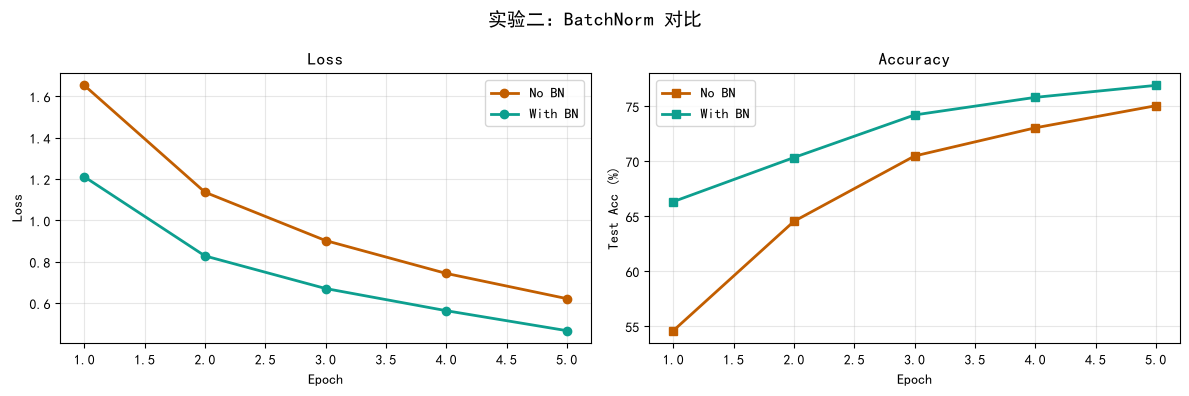

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, color, hist in experiments_bn:
    e = list(range(1, len(hist['train_loss']) + 1))
    axes[0].plot(e, hist['train_loss'], 'o-', color=color, linewidth=2, label=name)
    axes[1].plot(e, hist['test_acc'], 's-', color=color, linewidth=2, label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Acc (%)'); axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('实验二：BatchNorm 对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 实验二分析

通常会看到：
- 有 BN 的网络 loss 下降更快
- 有 BN 的网络准确率更高
- 有 BN 的网络训练更稳定

BatchNorm 现在几乎是 CV 网络的标配。


## 5. 实验三：Dropout 对比

### 5.1 什么是 Dropout？

Dropout 是 Hinton 等人提出的防止过拟合的方法。

训练时：以概率 $p$ 随机丢弃一部分神经元，让它们不参与前向和反向传播。
测试时：所有神经元都参与，但输出按 $1-p$ 缩放（或者等价的，训练时按 $1/(1-p)$ 缩放）。

### 5.2 Dropout 为什么能防止过拟合？

1. **减少神经元之间的共适应**：每个神经元不能依赖其他特定神经元
2. **隐式集成**：每次训练时用不同的子网络，相当于训练了多个模型
3. **强迫学习更鲁棒的特征**：因为神经元随时可能"被丢"


In [10]:
experiments_do = []

print("\n【实验 F】无 Dropout")
model = SimpleNet(use_bn=True, use_dropout=False).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion)
experiments_do.append(('No Dropout', '#c25e00', hist))

print("\n【实验 G】Dropout=0.5")
model = SimpleNet(use_bn=True, use_dropout=True, dropout_p=0.5).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion)
experiments_do.append(('Dropout=0.5', '#0d9f8f', hist))



【实验 F】无 Dropout
  Epoch 1/5: Loss=1.2205, Test Acc=65.26%
  Epoch 2/5: Loss=0.8249, Test Acc=69.53%
  Epoch 3/5: Loss=0.6668, Test Acc=71.90%
  Epoch 4/5: Loss=0.5563, Test Acc=74.50%
  Epoch 5/5: Loss=0.4597, Test Acc=77.87%

【实验 G】Dropout=0.5
  Epoch 1/5: Loss=1.3724, Test Acc=64.90%
  Epoch 2/5: Loss=1.0422, Test Acc=68.24%
  Epoch 3/5: Loss=0.9111, Test Acc=68.26%
  Epoch 4/5: Loss=0.8129, Test Acc=73.20%
  Epoch 5/5: Loss=0.7410, Test Acc=74.27%


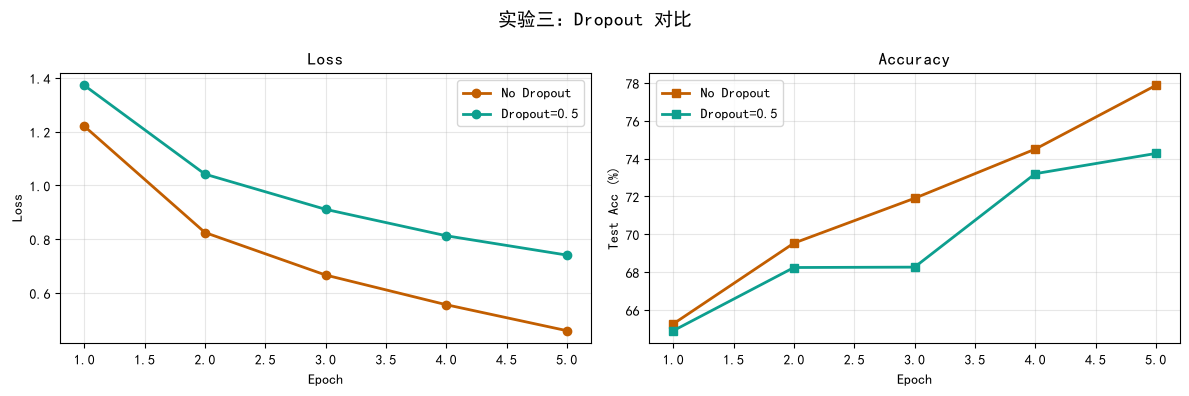

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, color, hist in experiments_do:
    e = list(range(1, len(hist['train_loss']) + 1))
    axes[0].plot(e, hist['train_loss'], 'o-', color=color, linewidth=2, label=name)
    axes[1].plot(e, hist['test_acc'], 's-', color=color, linewidth=2, label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Acc (%)'); axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('实验三：Dropout 对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 实验三分析

- 有 Dropout 的训练 loss 通常更高（因为神经元少了，拟合能力下降）
- 但测试准确率可能更高或更稳定（防止过拟合）
- Dropout 主要加在全连接层，卷积层通常不用


## 6. 实验四：学习率调度对比

### 6.1 为什么需要学习率调度？

训练初期：损失函数曲面比较陡峭，可以用大学习率快速下降。
训练后期：接近最优解，需要小学习率精细调整。

如果一直用固定学习率，可能会在最优解附近震荡。

### 6.2 两种常见调度策略

**Step Decay**：每隔 $N$ 个 epoch，把学习率乘以一个因子（如 0.1）。

**Cosine Annealing**：学习率按余弦函数从初始值下降到接近 0。

$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})(1 + \cos(\frac{t}{T}\pi))$$


In [12]:
experiments_lr = []

print("\n【实验 H】固定学习率")
model = SimpleNet(use_bn=True, use_dropout=False).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion)
experiments_lr.append(('Fixed LR', '#c25e00', hist))

print("\n【实验 I】Step Decay（每 2 epoch 乘 0.1）")
model = SimpleNet(use_bn=True, use_dropout=False).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion, scheduler)
experiments_lr.append(('Step Decay', '#0d9f8f', hist))

print("\n【实验 J】Cosine Annealing")
model = SimpleNet(use_bn=True, use_dropout=False).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
hist = train_experiment(model, train_loader, test_loader, epochs, optimizer, criterion, scheduler)
experiments_lr.append(('Cosine', '#d4a55f', hist))



【实验 H】固定学习率
  Epoch 1/5: Loss=1.2155, Test Acc=66.16%
  Epoch 2/5: Loss=0.8300, Test Acc=70.98%
  Epoch 3/5: Loss=0.6727, Test Acc=72.65%
  Epoch 4/5: Loss=0.5696, Test Acc=75.76%
  Epoch 5/5: Loss=0.4656, Test Acc=75.97%

【实验 I】Step Decay（每 2 epoch 乘 0.1）
  Epoch 1/5: Loss=1.2155, Test Acc=66.17%
  Epoch 2/5: Loss=0.8181, Test Acc=71.43%
  Epoch 3/5: Loss=0.5542, Test Acc=77.22%
  Epoch 4/5: Loss=0.5010, Test Acc=77.73%
  Epoch 5/5: Loss=0.4591, Test Acc=78.30%

【实验 J】Cosine Annealing
  Epoch 1/5: Loss=1.2248, Test Acc=65.31%
  Epoch 2/5: Loss=0.8232, Test Acc=68.69%
  Epoch 3/5: Loss=0.6227, Test Acc=74.17%
  Epoch 4/5: Loss=0.4694, Test Acc=78.20%
  Epoch 5/5: Loss=0.3510, Test Acc=79.92%


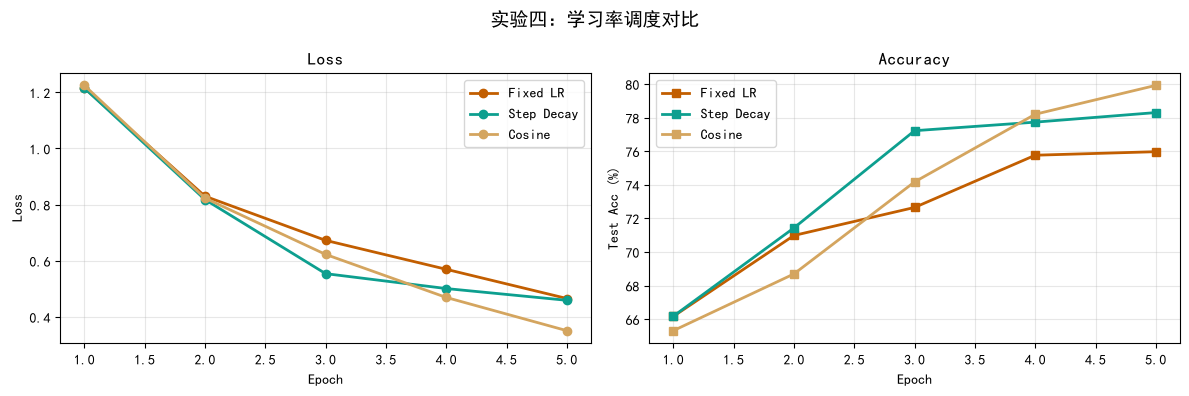

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, color, hist in experiments_lr:
    e = list(range(1, len(hist['train_loss']) + 1))
    axes[0].plot(e, hist['train_loss'], 'o-', color=color, linewidth=2, label=name)
    axes[1].plot(e, hist['test_acc'], 's-', color=color, linewidth=2, label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Acc (%)'); axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('实验四：学习率调度对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 实验四分析

- 固定学习率：可能下降最快，但后期可能震荡
- Step Decay：简单有效，是常用策略
- Cosine Annealing：平滑下降，在很多任务上表现好


## 7. 汇总所有结论


In [14]:
print("=" * 70)
print("训练技巧消融实验结论汇总")
print("=" * 70)

print("\n优化器:")
for name, _, hist in experiments:
    print(f"  {name:<20} 最终准确率: {hist['test_acc'][-1]:.2f}%")

print("\nBatchNorm:")
for name, _, hist in experiments_bn:
    print(f"  {name:<20} 最终准确率: {hist['test_acc'][-1]:.2f}%")

print("\nDropout:")
for name, _, hist in experiments_do:
    print(f"  {name:<20} 最终准确率: {hist['test_acc'][-1]:.2f}%")

print("\n学习率调度:")
for name, _, hist in experiments_lr:
    print(f"  {name:<20} 最终准确率: {hist['test_acc'][-1]:.2f}%")

print("=" * 70)


训练技巧消融实验结论汇总

优化器:
  SGD                  最终准确率: 67.42%
  SGD+Momentum         最终准确率: 77.36%
  Adam                 最终准确率: 76.62%

BatchNorm:
  No BN                最终准确率: 75.05%
  With BN              最终准确率: 76.90%

Dropout:
  No Dropout           最终准确率: 77.87%
  Dropout=0.5          最终准确率: 74.27%

学习率调度:
  Fixed LR             最终准确率: 75.97%
  Step Decay           最终准确率: 78.30%
  Cosine               最终准确率: 79.92%


## 8. 动手练习

### 练习 1：组合最佳配置
尝试同时打开 BatchNorm + Dropout + SGD+Momentum + CosineAnnealing，训练 10 个 epoch，看看能不能达到更高的准确率。

### 练习 2：增加 epochs
把 epochs 从 5 增加到 10，观察固定学习率和 CosineAnnealing 的差距是否变大。

### 练习 3：Weight Decay
在优化器里加 `weight_decay=5e-4`，观察对过拟合的影响：
```python
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
```

### 练习 4：画出学习率变化曲线
对于 Step Decay 和 Cosine Annealing，记录每个 epoch 的学习率，画出来看看。


## 9. 常见问题

**Q1：消融实验的结果每次运行都不一样，正常吗？**
A：正常。随机初始化会影响结果，但只要趋势一致（如 BN 加速收敛），就有参考价值。

**Q2：为什么 Adam 有时不如 SGD+Momentum？**
A：Adam 自适应学习率，收敛快，但可能收敛到较"宽"的最小值。SGD+Momentum 配合好的调度，可能找到更"尖锐"、泛化更好的最小值。

**Q3：BatchNorm 和 Dropout 能一起用吗？**
A：可以，但要注意顺序。通常BN在激活函数之前，Dropout在激活函数之后。现代网络中，Dropout 用得越来越少了，因为 BN 本身有正则化效果。


## 10. 小结

- **优化器**：SGD+Momentum 和 Adam 最常用
- **BatchNorm**：加速收敛、稳定训练、允许大学习率
- **Dropout**：防止过拟合，全连接层常用
- **学习率调度**：让模型后期精细收敛
- 实际炼丹时，这些技巧通常组合使用

模块一到这里就结束了。接下来我们将进入目标检测（YOLO）。
